<a href="https://colab.research.google.com/github/oliviapang/scratchpad/blob/main/demand_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
! git clone https://github.com/oliviapang/scratchpad

Cloning into 'scratchpad'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 72 (delta 20), reused 5 (delta 5), pack-reused 35 (from 2)
Receiving objects: 100% (72/72), 18.30 MiB | 8.33 MiB/s, done.
Resolving deltas: 100% (27/27), done.


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Question 1

In [11]:
df = pd.read_parquet('/content/scratchpad/demand_1.parquet')
df.head()

,user_id,year,choice,brand,parent_asin,product_title,price,average_rating,waterproof_flag,party_flag,voice_assistant_flag,purchase_dt
0,AE224SS3CBECXN5SGPRY5WW7TU4Q,2015,JBL,jbl,B00GAJ2OK4,JBL Flip 2 Portable Wireless Speaker (Black),55.00,4.5,False,False,False,2015-05-24 23:39:26
1,AE22AIEZGF67Z65KRCQGPLGVDZRQ,2015,Other,unknown,B00KWU863Q,"Logitech X300 Mobile Wireless Stereo Speaker, ...",39.95,4.3,False,False,False,2015-01-28 21:14:58
2,AE22ZDVFW5T2Y37QBP2W6HP2LMWA,2015,Other,creative,B003N9PJDI,Creative D200 Bluetooth Speaker,49.99,4.4,False,False,False,2015-03-17 01:35:18
3,AE23CACEREJI2O6X7RWTNRF2NUDQ,2015,Bose,bose,B01AS57B0I,Bose SoundLink Color Bluetooth Speaker (Blue),99.99,4.6,False,False,False,2015-02-14 18:14:52
4,AE23GFJX7BXK77S7C34AHWXPCJEQ,2015,Other,jawbone,B0087BDWBI,"Jawbone Jambox Bluetooth Speaker, Diamond Blac...",69.99,4.3,False,False,False,2015-06-15 19:54:38


/tmp/ipykernel_1088/3024090969.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data = df, x = 'price', hue = 'brand')


<Axes: xlabel='price', ylabel='Density'>

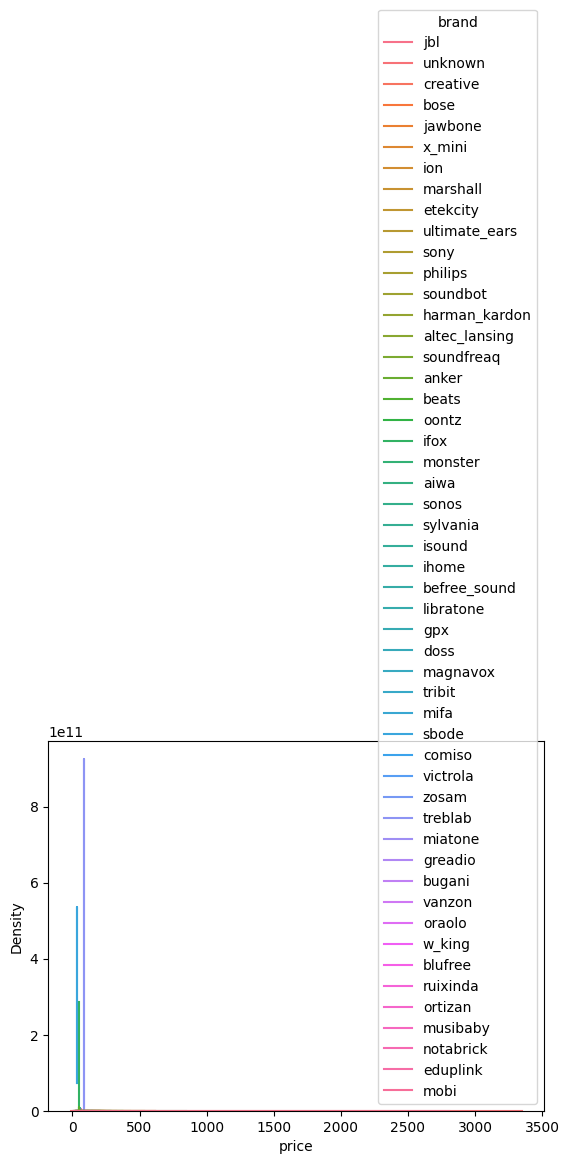

In [13]:
sns.kdeplot(data = df, x = 'price', hue = 'brand')

Question 2

In [14]:
brand_df = pd.read_parquet('/content/scratchpad/demand_2.parquet')

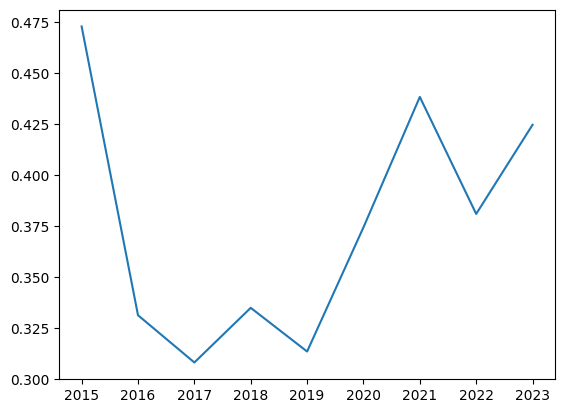

In [18]:
brand_df['sh_sq'] = brand_df['share_among_speaker_buyers']**2
#brand_df.head()
hhi = brand_df.loc[:, ['sh_sq', 'year']].groupby('year').sum()
plt.plot(hhi)

In [ ]:
#hhi_df = (brand_df.loc[:, ['sh_sq', 'year']].groupby('year', as_index).sum()

Question 3

In [22]:
consumer_df = pd.read_parquet('/content/scratchpad/demand_3.parquet')
consumer_df.head()

,year,choice,chosen_users,avg_price,avg_rating,waterproof_share,party_share,voice_assistant_share,speaker_buyers,share_among_speaker_buyers,base_share,log_share_diff
0,2015,Anker,79,63.329873,4.529114,0.000000,0.0,0.000000,20029,0.003944,0.639173,-5.087909
1,2015,Bose,4212,141.189855,4.533974,0.000000,0.0,0.000000,20029,0.210295,0.639173,-1.111664
2,2015,JBL,2832,78.035332,4.383510,0.000353,0.0,0.000000,20029,0.141395,0.639173,-1.508618
3,2015,OontZ,104,45.456538,3.659615,0.000000,0.0,0.903846,20029,0.005192,0.639173,-4.812966
4,2016,Anker,2982,37.254859,4.679376,0.000000,0.0,0.000000,26429,0.112831,0.491354,-1.471278


In [23]:
consumer_df.columns

Index(['year', 'choice', 'chosen_users', 'avg_price', 'avg_rating',
       'waterproof_share', 'party_share', 'voice_assistant_share',
       'speaker_buyers', 'share_among_speaker_buyers', 'base_share',
       'log_share_diff'],
      dtype='object')

In [ ]:
['avg_price', 'avg_rating','waterproof_share', 'party_share', 'voice_assistant_share']

In [28]:
from sklearn.linear_model import LinearRegression
y = consumer_df['log_share_diff']
ohc_brand = pd.get_dummies(consumer_df['choice'], dtype = int, drop_first = True)
ohc_year = pd.get_dummies(consumer_df['year'], dtype = int, drop_first = True, prefix = 'year')
X_num = consumer_df.loc[:, ['avg_price', 'avg_rating','waterproof_share', 'party_share', 'voice_assistant_share']]
X = pd.concat([X_num, ohc_brand, ohc_year], axis = 1)
model = LinearRegression()
model = model.fit(X,y)